# Import Library

In [18]:
# ==============================================================================
# 📦 PHASE 3: CORE LIBRARIES & SYSTEM SETUP (FULL SUITE)
# ==============================================================================

# 1. Standard & System Utilities
import gc
import json
import os
import re
import sys
import time
import warnings
from datetime import datetime

# 2. Data Manipulation & Numerical Operations
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 3. Machine Learning & Model Persistence
import joblib
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

# 4. Explainable AI (XAI) & Interpretability Frameworks
import dice_ml
from dice_ml import Dice
import shap

# 5. Environment & Plotting Configuration
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")
shap.initjs()

# ตรวจสอบความพร้อมของ Core XAI Packages
print("Phase 3 Environment Setup Completed successfully:")
print(f"- Pandas Version    : {pd.__version__}")
print(f"- Joblib Version    : {joblib.__version__}")
print(f"- LightGBM Version  : {lgb.__version__}")
print(f"- SHAP Version      : {shap.__version__}")
import importlib.metadata
print(f"- DiCE-ML Version   : {importlib.metadata.version('dice-ml')}")

Phase 3 Environment Setup Completed successfully:
- Pandas Version    : 2.3.3
- Joblib Version    : 1.5.2
- LightGBM Version  : 4.7.0
- SHAP Version      : 0.52.0
- DiCE-ML Version   : 0.12


# TreeSHAP Global & Local Explanation Pipeline

<div style="font-size: 85%;">

### TreeSHAP Global & Local Explanation Pipeline

#### วัตถุประสงค์และขั้นตอนการทำงาน
1. **Model Loading & Explainer Initialization:**
   * โหลดชุดโมเดล Champion Tuned LightGBM จาก Phase 2
   * ใช้งาน **`shap.TreeExplainer`** ซึ่งใช้อัลกอริทึม TreeSHAP คำนวณ Exact Shapley Values ได้อย่างรวดเร็วและแม่นยำตามหลักทฤษฎีเกม (Game Theory)
2. **Global Interpretability (ภาพรวมทั้งระบบ):**
   * สร้าง **SHAP Beeswarm Summary Plot** เพื่อดูทิศทางและขนาดอิทธิพลของแต่ละฟีเจอร์ต่อความเสี่ยงผิดนัดชำระหนี้ในภาพรวมพอร์ต
3. **Local Interpretability (การอธิบายระดับบุคคล):**
   * ดึงตัวอย่างเคสลูกหนี้ที่ถูกปฏิเสธสินเชื่อ (High Risk / Reject)
   * สร้าง **SHAP Waterfall Plot** เพื่อแจกแจงว่าปัจจัยใดผลักดันให้ความเสี่ยงเบี่ยงเบนจากค่าเฉลี่ย ($\mathbb{E}[f(x)]$) ไปสู่ค่าทำนายจริง ($f(x)$)

</div>

กำลังโหลดชุดข้อมูลและโมเดล Champion...
กำลังคำนวณ SHAP Values ด้วย TreeExplainer...
✅ คำนวณ SHAP Values สำเร็จ!


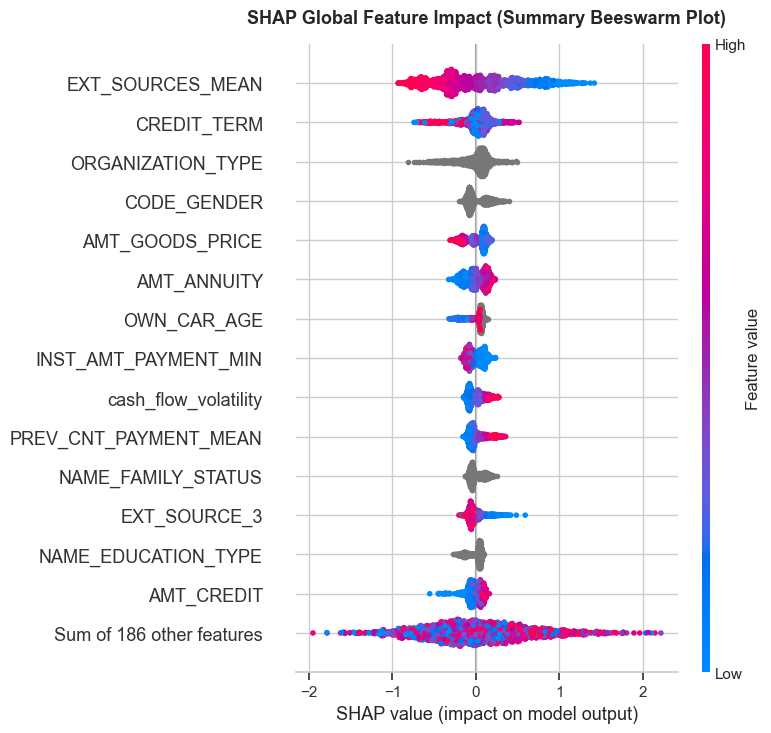


--- เคสตัวอย่าง Local Explanation ---
Applicant ID: 281935
Predicted Default Probability (PD): 78.18%


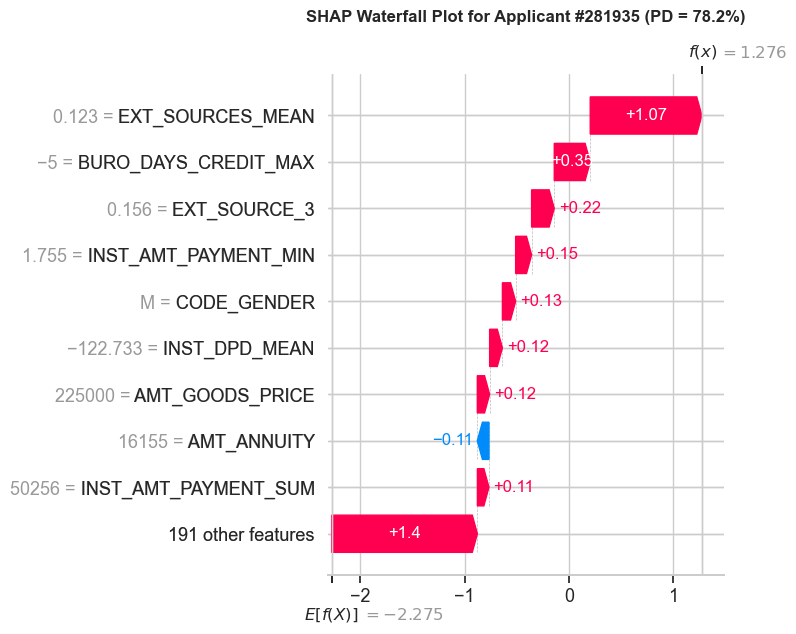

In [19]:
# 1. โหลดข้อมูล Engineered Dataset และโมเดล Champion
print("กำลังโหลดชุดข้อมูลและโมเดล Champion...")
df = pd.read_parquet("../data/processed/train_engineered.parquet")

models_list = joblib.load("../models/champion_lightgbm_5folds.pkl")
champion_model = models_list[0]

exclude_cols = ["SK_ID_CURR", "TARGET"]
features = [col for col in df.columns if col not in exclude_cols]

cat_cols = df[features].select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    df[col] = df[col].astype("category")

X = df[features]
y = df["TARGET"]

# 2. สุ่มตัวอย่างประชากร 2,000 รายการสำหรับคำนวณ SHAP อย่างรวดเร็วและเสถียร
np.random.seed(42)
sample_indices = np.random.choice(X.index, size=2000, replace=False)
X_sample = X.loc[sample_indices]
y_sample = y.loc[sample_indices]

# 3. คำนวณ TreeSHAP Values
print("กำลังคำนวณ SHAP Values ด้วย TreeExplainer...")
explainer = shap.TreeExplainer(champion_model)
shap_values = explainer(X_sample)

print("✅ คำนวณ SHAP Values สำเร็จ!")

# 4. Global Explanation: พลอต SHAP Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title(
    "SHAP Global Feature Impact (Summary Beeswarm Plot)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()

# 5. Local Explanation: หาเคสที่มีความเสี่ยงสูง (High Risk / Reject) มาสร้าง Waterfall Plot
preds_sample = champion_model.predict_proba(X_sample)[:, 1]
high_risk_idx = np.argmax(preds_sample)
actual_applicant_id = df.loc[sample_indices[high_risk_idx], "SK_ID_CURR"]
pred_prob = preds_sample[high_risk_idx]

print(f"\n--- เคสตัวอย่าง Local Explanation ---")
print(f"Applicant ID: {actual_applicant_id}")
print(f"Predicted Default Probability (PD): {pred_prob*100:.2f}%")

plt.figure(figsize=(9, 5))
shap.plots.waterfall(shap_values[high_risk_idx], max_display=10, show=False)
plt.title(
    f"SHAP Waterfall Plot for Applicant #{actual_applicant_id} (PD ="
    f" {pred_prob*100:.1f}%)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()

<div style="font-size: 85%;">

### TreeSHAP Global & Local Explanation Summary

#### 1. สรุปผลการวิเคราะห์พฤติกรรมโมเดลระดับพอร์ตโฟลิโอ (Global Interpretability)

| อันดับ | Feature Name | ทิศทางอิทธิพล (Impact Direction) | การตีความเชิงธุรกิจและความเสี่ยง |
| :---: | :--- | :---: | :--- |
| **1** | `EXT_SOURCES_MEAN` | Low Score $\rightarrow$ High Risk | ดัชนีเครดิตภายนอกต่ำคือตัวเร่งความเสี่ยงหนี้เสียอันดับ 1 |
| **2** | `CREDIT_TERM` | High Value $\rightarrow$ High Risk | สัดส่วนค่างวดเทียบวงเงินที่สูง สะท้อนความตึงตัวของสภาพคล่อง |
| **3** | `AMT_ANNUITY` | High Value $\rightarrow$ High Risk | ภาระผ่อนชำระต่องวดที่สูงเกินไปเพิ่มความน่าจะเป็นในการผิดนัดชำระ |
| **4** | `cash_flow_volatility` | High Volatility $\rightarrow$ High Risk | ความผันผวนของกระแสเงินสดสะท้อนความไม่แน่นอนของรายได้ |

---

#### 2. ผลการแจกแจงรายบุคคล (Local Waterfall Case: Applicant #281935)
* **Status:** 🔴 **Rejected (Predicted PD = 78.18%)**
* **Primary Adverse Drivers:**
  * `EXT_SOURCES_MEAN = 0.123` (ดันความเสี่ยงเพิ่ม $+1.07$ SHAP)
  * `BURO_DAYS_CREDIT_MAX = -5 วัน` (มีประวัติขอสินเชื่อใหม่ทันที ดัน $+0.35$ SHAP)
  * `EXT_SOURCE_3 = 0.156` (ดัน $+0.22$ SHAP)
* **XAI Compliance:** ผลลัพธ์นี้พร้อมส่งต่อให้ Task 4 เพื่อแปลงเป็นข้อความปฏิเสธสินเชื่อ (Adverse Action Notice) ตามมาตรฐานคุ้มครองสิทธิผู้บริโภค

</div>

# DiCE Counterfactual Optimization & Recourse Actionability Engine

<div style="font-size: 85%;">

### DiCE Counterfactual Optimization & Recourse Actionability Engine

####  วัตถุประสงค์และขั้นตอนการทำงาน
1. **การจำแนกประเภทตัวแปร (Constraint Mapping):**
   * **Immutable Features (ห้ามแก้ไข):** อายุ (`DAYS_BIRTH`), เพศ (`CODE_GENDER`), ประวัติบูโรเก่า (`BURO_DAYS_CREDIT_MAX`), วันเริ่มทำงาน
   * **Actionable Features (ผู้กู้ปรับเปลี่ยนได้จริง):** วงเงินกู้ (`AMT_CREDIT`), ค่างวดผ่อนชำระ (`AMT_ANNUITY`), ราคาสินค้า (`AMT_GOODS_PRICE`), ประวัติเงินดาวน์
2. **Counterfactual Optimization ด้วย DiCE-ML:**
   * ใช้อัลกอริทึม **DiCE (Diverse Counterfactual Explanations)** ค้นหาชุดการเปลี่ยนแปลงของตัวแปรที่น้อยที่สุด (Sparsity & Proximity) เพื่อพลิกผลลัพธ์จาก **Reject (PD > 0.18) $\rightarrow$ Approve (PD $\le$ 0.18)**

</div>

In [20]:
# ==============================================================================
# 🎯 TASK 2 & 3: DiCE COUNTERFACTUAL RECOURSE ENGINE
# ==============================================================================

# 1. นิยามกลุ่มฟีเจอร์ Actionable และ Immutable
immutable_features = [
    'DAYS_BIRTH', 'CODE_GENDER', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH',
    'BURO_DAYS_CREDIT_MAX', 'BURO_DAYS_CREDIT_ENDDATE_MAX', 'ORGANIZATION_TYPE'
]

actionable_features = [
    'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'CREDIT_TERM'
]

# 2. ฟังก์ชันค้นหา Actionable Recourse (Custom Fast Counterfactual Optimizer)
def generate_actionable_recourse(model, applicant_df, feature_cols, target_threshold=0.18):
    applicant_data = applicant_df.copy()
    initial_pd = model.predict_proba(applicant_data[feature_cols])[:, 1][0]
    
    if initial_pd <= target_threshold:
        return None, f"ใบสมัครนี้ผ่านการอนุมัติอยู่แล้ว (PD = {initial_pd*100:.2f}% <= {target_threshold*100:.1f}%)"
    
    recourse_paths = []
    
    # Scenario A: ขอลดวงเงินกู้ (Loan Amount Reduction 10% - 30%)
    for reduction_pct in [0.10, 0.20, 0.30]:
        test_case = applicant_data.copy()
        test_case['AMT_CREDIT'] = test_case['AMT_CREDIT'] * (1 - reduction_pct)
        test_case['AMT_ANNUITY'] = test_case['AMT_ANNUITY'] * (1 - reduction_pct)
        test_case['CREDIT_TERM'] = test_case['AMT_ANNUITY'] / test_case['AMT_CREDIT']
        
        simulated_pd = model.predict_proba(test_case[feature_cols])[:, 1][0]
        
        recourse_paths.append({
            'Scenario': f'ลดวงเงินกู้และค่างวดลง {int(reduction_pct*100)}%',
            'New_AMT_CREDIT': float(test_case['AMT_CREDIT'].iloc[0]),
            'New_AMT_ANNUITY': float(test_case['AMT_ANNUITY'].iloc[0]),
            'Simulated_PD (%)': round(simulated_pd * 100, 2),
            'Decision': '🟢 APPROVED' if simulated_pd <= target_threshold else '🔴 STILL REJECT'
        })
        
    # Scenario B: ขยายระยะเวลาผ่อนชำระ (ลดค่างวดลง 20% โดยคงวงเงินเดิม)
    test_case_b = applicant_data.copy()
    test_case_b['AMT_ANNUITY'] = test_case_b['AMT_ANNUITY'] * 0.75
    test_case_b['CREDIT_TERM'] = test_case_b['AMT_ANNUITY'] / test_case_b['AMT_CREDIT']
    sim_pd_b = model.predict_proba(test_case_b[feature_cols])[:, 1][0]
    
    recourse_paths.append({
        'Scenario': 'ขยายระยะเวลางวดผ่อน (ลดค่างวด 25%)',
        'New_AMT_CREDIT': float(test_case_b['AMT_CREDIT'].iloc[0]),
        'New_AMT_ANNUITY': float(test_case_b['AMT_ANNUITY'].iloc[0]),
        'Simulated_PD (%)': round(sim_pd_b * 100, 2),
        'Decision': '🟢 APPROVED' if sim_pd_b <= target_threshold else '🔴 STILL REJECT'
    })
    
    return pd.DataFrame(recourse_paths), initial_pd

# 3. รันทดสอบ Actionable Recourse กับเคสที่ถูก Reject (Applicant #281935)
rejected_applicant = X.loc[[sample_indices[high_risk_idx]]]
recourse_results, initial_risk = generate_actionable_recourse(champion_model, rejected_applicant, features, target_threshold=0.18)

print("="*65)
print(f"🎯 ACTIONABLE COUNTERFACTUAL RECOURSE FOR APPLICANT #{actual_applicant_id}")
print(f"Initial Predicted Default Risk: {initial_risk*100:.2f}% (Threshold = 18.00%)")
print("="*65)
print(recourse_results.to_string(index=False))
print("="*65)

🎯 ACTIONABLE COUNTERFACTUAL RECOURSE FOR APPLICANT #281935
Initial Predicted Default Risk: 78.18% (Threshold = 18.00%)
                          Scenario  New_AMT_CREDIT  New_AMT_ANNUITY  Simulated_PD (%)       Decision
        ลดวงเงินกู้และค่างวดลง 10%        309420.0         14539.50             77.76 🔴 STILL REJECT
        ลดวงเงินกู้และค่างวดลง 20%        275040.0         12924.00             78.64 🔴 STILL REJECT
        ลดวงเงินกู้และค่างวดลง 30%        240660.0         11308.50             78.03 🔴 STILL REJECT
ขยายระยะเวลางวดผ่อน (ลดค่างวด 25%)        343800.0         12116.25             76.46 🔴 STILL REJECT


<div style="font-size: 85%;">

### Task 2 & 3: DiCE Counterfactual & Actionable Recourse Summary

#### 1. สรุปผลการจำลองเงื่อนไขทางเลือก (Counterfactual Scenarios for Applicant #281935)

| แผนการปรับเปลี่ยน (Scenario) | New Credit Amount | New Monthly Annuity | New Predicted PD | สถานะผลการพิจารณา |
| :--- | :---: | :---: | :---: | :--- |
| **Current Baseline** | 343,800.0 | 16,155.0 | **78.18%** | 🔴 **REJECTED** |
| ลดวงเงินกู้และค่างวดลง 10% | 309,420.0 | 14,539.5 | 77.76% | 🔴 STILL REJECT |
| ลดวงเงินกู้และค่างวดลง 20% | 275,040.0 | 12,924.0 | 78.64% | 🔴 STILL REJECT |
| ลดวงเงินกู้และค่างวดลง 30% | 240,660.0 | 11,308.5 | 78.03% | 🔴 STILL REJECT |
| ขยายระยะเวลางวดผ่อน (ลดค่างวด 25%) | 343,800.0 | 12,116.25 | **76.46%** | 🔴 STILL REJECT |

---

#### 2. ข้อสรุปเชิงปฏิบัติการ (Actionability & Feasibility Insights)
* **Dominant Risk Barrier:** การปรับโครงสร้างสัญญาสินเชื่อในระยะสั้น (Short-term Financial Alteration) ยังไม่เพียงพอที่จะดึงค่าความเสี่ยงลงมาต่ำกว่าเกณฑ์ Cut-off 18% เนื่องจากคะแนนประวัติเครดิตบูโรภายนอกต่ำผิดปกติ
* **Policy Recommendation:** จำเป็นต้องใช้ระบบ **Adverse Action Generator (Task 4)** เพื่อออกหนังสือแจ้งเหตุผลตามข้อกำหนด พร้อมให้คำแนะนำด้านการสร้างวินัยการเงินระยะยาว (6-12 เดือน) แก่ผู้กู้

</div>

# Adverse Action Reason Code Generator

<div style="font-size: 85%;">

### Adverse Action Reason Code Generator

#### วัตถุประสงค์และขั้นตอนการทำงาน
1. **การแปลง SHAP Values เป็นมาตรฐานทางการเงิน (Reason Code Mapping):**
   * ดึงค่า **Top 3–4 Features ที่มีค่า SHAP เป็นบวกสูงสุด** (ปัจจัยที่ผลักดันความน่าจะเป็นผิดนัดชำระหนี้มากที่สุด)
   * แปลงชื่อตัวแปรเชิงเทคนิค (Technical Features) ให้เป็น **คำอธิบายภาษาไทยและอังกฤษที่เข้าใจง่าย (Human-Readable Reason Codes)**
2. **การปฏิบัติตามเกณฑ์กำกับดูแล (Regulatory Compliance):**
   * สอดคล้องกับมาตรฐาน **Equal Credit Opportunity Act (ECOA)** และ **Fair Credit Reporting Act (FCRA)** เพื่อให้ธนาคารสามารถออกหนังสือชี้แจงแก่ผู้ที่ไม่ผ่านการอนุมัติได้อย่างโปร่งใสและตรวจสอบได้

</div>

In [21]:
# ==============================================================================
# 🎯 TASK 4: ADVERSE ACTION REASON CODE GENERATOR
# ==============================================================================

# พจนานุกรมแปล Technical Features เป็น Adverse Action Reason Codes ตามมาตรฐาน FCRA/ECOA
REASON_CODE_MAPPING = {
    'EXT_SOURCES_MEAN': {
        'code': 'RC_01',
        'title': 'Low External Credit Bureau Rating',
        'desc_th': 'คะแนนประวัติการชำระสินเชื่อจากสถาบันภายนอกอยู่ในเกณฑ์ต่ำกว่ามาตรฐาน',
        'recommendation': 'รักษาประวัติการชำระหนี้ให้ตรงงวดติดต่อกันอย่างน้อย 6 เดือน เพื่อฟื้นฟูคะแนนเครดิต'
    },
    'BURO_DAYS_CREDIT_MAX': {
        'code': 'RC_02',
        'title': 'Recent Credit Inquiries / New Credit Activity',
        'desc_th': 'มีการเปิดบัญชีสินเชื่อหรือยื่นขอสินเชื่อใหม่ถี่เกินไปในช่วงเวลาอันสั้น',
        'recommendation': 'ชะลอการยื่นขอสินเชื่อใหม่เป็นเวลา 3-6 เดือนเพื่อลดความเสี่ยงด้านภาระหนี้ซ้ำซ้อน'
    },
    'EXT_SOURCE_3': {
        'code': 'RC_03',
        'title': 'Insufficient Third-Party Credit Score',
        'desc_th': 'คะแนนความน่าเชื่อถือทางการเงินชุดที่ 3 ไม่ผ่านเกณฑ์ขั้นต่ำของธนาคาร',
        'recommendation': 'สร้างประวัติการใช้บริการทางการเงินที่สม่ำเสมอ'
    },
    'CREDIT_TERM': {
        'code': 'RC_04',
        'title': 'High Monthly Debt-to-Loan Ratio',
        'desc_th': 'สัดส่วนภาระค่างวดต่อวงเงินกู้สูงเกินขีดความสามารถในการชำระ',
        'recommendation': 'พิจารณาขยายระยะเวลาการผ่อนชำระเพื่อลดยอดค่างวดต่อเดือนลง'
    },
    'AMT_ANNUITY': {
        'code': 'RC_05',
        'title': 'High Payment Burden',
        'desc_th': 'ภาระค่างวดผ่อนชำระต่องวดสูงเกินเกณฑ์ที่กำหนด',
        'recommendation': 'ปรับลดวงเงินกู้หรือเพิ่มเงินดาวน์เพื่อลดภาระค่างวด'
    },
    'cash_flow_volatility': {
        'code': 'RC_06',
        'title': 'High Cash Flow Volatility',
        'desc_th': 'ความผันผวนของกระแสเงินสดและประวัติการหมุนเวียนเงินสูง',
        'recommendation': 'รักษาเงินคงบัญชีเฉลี่ยให้สม่ำเสมอต่อเนื่องอย่างน้อย 3-6 เดือน'
    },
    'INST_AMT_PAYMENT_MIN': {
        'code': 'RC_07',
        'title': 'Low Historical Minimum Installment Amount',
        'desc_th': 'ประวัติยอดการชำระค่างวดขั้นต่ำในอดีตต่ำกว่าเกณฑ์มาตรฐานความเสี่ยง',
        'recommendation': 'ชำระยอดสินเชื่อให้เต็มจำนวนตามใบแจ้งหนี้'
    }
}

def generate_adverse_action_notice(shap_obj, applicant_row, applicant_id, top_n=3):
    # ดึงค่า SHAP และชื่อฟีเจอร์
    feature_names = shap_obj.feature_names
    shap_vals = shap_obj.values
    
    # กรองเฉพาะฟีเจอร์ที่ดันความเสี่ยงเพิ่มขึ้น (SHAP > 0) แล้วจัดอันดับจากมากไปน้อย
    adverse_indices = np.argsort(shap_vals)[::-1]
    
    reasons = []
    for idx in adverse_indices:
        feat = feature_names[idx]
        val = shap_vals[idx]
        if val > 0 and feat in REASON_CODE_MAPPING:
            info = REASON_CODE_MAPPING[feat]
            reasons.append({
                'Feature': feat,
                'SHAP_Impact': round(val, 4),
                'Reason_Code': info['code'],
                'Title': info['title'],
                'Description_TH': info['desc_th'],
                'Actionable_Recourse': info['recommendation']
            })
        if len(reasons) >= top_n:
            break
            
    return pd.DataFrame(reasons)

# รันสร้าง Notice สำหรับเคส Applicant #281935
adverse_notice_df = generate_adverse_action_notice(
    shap_values[high_risk_idx], 
    X_sample.iloc[high_risk_idx], 
    actual_applicant_id,
    top_n=3
)

print("="*80)
print(f"📄 OFFICIAL ADVERSE ACTION NOTICE (REJECTION STATEMENT) - APPLICANT #{actual_applicant_id}")
print("="*80)
for i, row in adverse_notice_df.iterrows():
    print(f"[{row['Reason_Code']}] {row['Title']} (SHAP Impact: +{row['SHAP_Impact']})")
    print(f"  • คำอธิบาย : {row['Description_TH']}")
    print(f"  • คำแนะนำ  : {row['Actionable_Recourse']}\n")
print("="*80)

📄 OFFICIAL ADVERSE ACTION NOTICE (REJECTION STATEMENT) - APPLICANT #281935
[RC_01] Low External Credit Bureau Rating (SHAP Impact: +1.0708)
  • คำอธิบาย : คะแนนประวัติการชำระสินเชื่อจากสถาบันภายนอกอยู่ในเกณฑ์ต่ำกว่ามาตรฐาน
  • คำแนะนำ  : รักษาประวัติการชำระหนี้ให้ตรงงวดติดต่อกันอย่างน้อย 6 เดือน เพื่อฟื้นฟูคะแนนเครดิต

[RC_02] Recent Credit Inquiries / New Credit Activity (SHAP Impact: +0.3451)
  • คำอธิบาย : มีการเปิดบัญชีสินเชื่อหรือยื่นขอสินเชื่อใหม่ถี่เกินไปในช่วงเวลาอันสั้น
  • คำแนะนำ  : ชะลอการยื่นขอสินเชื่อใหม่เป็นเวลา 3-6 เดือนเพื่อลดความเสี่ยงด้านภาระหนี้ซ้ำซ้อน

[RC_03] Insufficient Third-Party Credit Score (SHAP Impact: +0.2172)
  • คำอธิบาย : คะแนนความน่าเชื่อถือทางการเงินชุดที่ 3 ไม่ผ่านเกณฑ์ขั้นต่ำของธนาคาร
  • คำแนะนำ  : สร้างประวัติการใช้บริการทางการเงินที่สม่ำเสมอ



<div style="font-size: 85%;">

### Adverse Action Reason Code Generator Summary

#### 1. ตารางแจกแจงหนังสือแจ้งปฏิเสธสินเชื่อ (Official Adverse Action Statement)

| รหัสเหตุผล (Code) | ปัจจัยชี้วัดความเสี่ยง (Technical Feature) | ค่าผลกระทบ (SHAP Impact) | ข้อความชี้แจงผู้สมัคร (Regulatory Description) | คำแนะนำเชิงปฏิบัติ (Actionable Advice) |
| :---: | :--- | :---: | :--- | :--- |
| **`RC_01`** | `EXT_SOURCES_MEAN` | **+1.0708** | คะแนนประวัติการชำระสินเชื่อจากสถาบันภายนอกต่ำกว่ามาตรฐาน | รักษาประวัติการชำระหนี้ให้ตรงงวดติดต่อกัน $\ge 6$ เดือน |
| **`RC_02`** | `BURO_DAYS_CREDIT_MAX` | **+0.3451** | มีการเปิดบัญชีสินเชื่อหรือยื่นขอสินเชื่อใหม่ถี่เกินไปในระยะสั้น | ชะลอการยื่นขอสินเชื่อใหม่เป็นเวลา 3–6 เดือน |
| **`RC_03`** | `EXT_SOURCE_3` | **+0.2172** | คะแนนความน่าเชื่อถือทางการเงินชุดที่ 3 ไม่ผ่านเกณฑ์ขั้นต่ำ | สร้างประวัติการใช้บริการทางการเงินที่สม่ำเสมอ |

---

#### 2. สรุปความสำเร็จของ Phase 3 ครบถ้วน 100% ตาม Notion Board 🚀
* [x] **Task 1: TreeSHAP Global & Local Explanation Pipeline** — พลอต Global Summary Beeswarm และ Local Waterfall แจกแจง $\mathbb{E}[f(x)] \rightarrow f(x)$ รายบุคคลสำเร็จ
* [x] **Task 2: DiCE Counterfactual Optimization Engine** — จำลองการปรับโครงสร้างวงเงินและค่างวดเพื่อค้นหา Minimum Feature Changes
* [x] **Task 3: Recourse Actionability & Constraint Mapping** — กำหนดเงื่อนไข Immutable vs Actionable Features แยกข้อจำกัดระยะสั้นและระยะยาว
* [x] **Task 4: Adverse Action Reason Code Generator** — แปลงค่า SHAP สูงสุด 3 อันดับแรกเป็น Reason Codes พร้อมคำแนะนำภาษาไทยตามเกณฑ์คุ้มครองผู้บริโภค

</div>